In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
import itertools

# Set style
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})

In [11]:
def load_data():
    # Files are in the same directory as the notebook
    metrics_dir = os.getcwd()
    
    # 1. Load Channel-wise metrics (from make_metrics.py / results_processor.py)
    channel_file = "all_networks_metrics_from_processor.csv"
    channel_path = os.path.join(metrics_dir, channel_file)
    
    if os.path.exists(channel_path):
        df_channel = pd.read_csv(channel_path)
        # Rename ADAPT to Adapt if present
        if "ADAPT" in df_channel.columns:
            df_channel.rename(columns={"ADAPT": "Adapt"}, inplace=True)
        print(f"Loaded Channel Metrics: {channel_file} ({len(df_channel)} rows)")
    else:
        print(f"Missing: {channel_file}")
        df_channel = pd.DataFrame()

    # 2. Load Parallel metrics (from make_metrics_3.py)
    parallel_file = "parallel_metrics_all_adapts.csv"
    parallel_path = os.path.join(metrics_dir, parallel_file)
    
    if os.path.exists(parallel_path):
        df_parallel = pd.read_csv(parallel_path)
        # Rename ADAPT to Adapt if present
        if "ADAPT" in df_parallel.columns:
            df_parallel.rename(columns={"ADAPT": "Adapt"}, inplace=True)
        print(f"Loaded Parallel Metrics: {parallel_file} ({len(df_parallel)} rows)")
    else:
        print(f"Missing: {parallel_file}")
        df_parallel = pd.DataFrame()
        
    return df_channel, df_parallel

In [12]:
# def load_data():
#     # Determine directory relative to this script
#     script_dir = os.path.dirname(os.getcwd())
#     metrics_dir = os.path.join(script_dir,"metrics")
    
#     adapt = [0, 120, 20, 2]
#     test_ds_b4 = False
    
#     combined_results = []
    
#     print(f"Loading metrics from: {metrics_dir}")
    
#     for a in adapt:
#         if test_ds_b4:
#             identifier = f"testing_dsb4_adaptable{a}" if a > 0 else "testing_dsb4"
#         else:
#             identifier = f"30000_1000_100_adaptable{a}" if a > 0 else "30000_1000_100"
            
#         filename = f"channel_metrics_by_network_{identifier}.csv"
#         path = os.path.join(metrics_dir, filename)
        
#         if os.path.exists(path):
#             df = pd.read_csv(path)
#             df["Adapt"] = a
#             combined_results.append(df)
#             print(f"Loaded: {filename}")
#         else:
#             print(f"Missing: {filename}")
            
#     if combined_results:
#         return pd.concat(combined_results, ignore_index=True)
#     else:
#         return pd.DataFrame()

In [13]:
df_channel, df_parallel = load_data()

# Display first few rows
print("\n--- Channel Metrics Head ---")
display(df_channel.head())

print("\n--- Parallel Metrics Head ---")
display(df_parallel.head())

Loaded Channel Metrics: all_networks_metrics_from_processor.csv (1536 rows)
Loaded Parallel Metrics: parallel_metrics_all_adapts.csv (192 rows)

--- Channel Metrics Head ---


,Session,Channel,Network,Adapt,Kappa,TP,FP,FN,Precision,Recall,F1,Num_Spikes,Num_Ripples,Mean_Latency
0,Amigo2_2019-07-11_11-57-07,0,dsb4updn_median_200_15f,0,0.028970,217,786,7,0.216351,0.968750,0.353708,8554,224,NaN
1,Amigo2_2019-07-11_11-57-07,1,dsb4updn_median_200_15f,0,0.014240,205,480,19,0.299270,0.915179,0.451045,8554,224,NaN
2,Amigo2_2019-07-11_11-57-07,2,dsb4updn_median_200_15f,0,-0.001103,184,259,40,0.415350,0.821429,0.551724,8554,224,NaN
3,Amigo2_2019-07-11_11-57-07,3,dsb4updn_median_200_15f,0,-0.015464,149,112,75,0.570881,0.665179,0.614433,8554,224,NaN
4,Amigo2_2019-07-11_11-57-07,4,dsb4updn_median_200_15f,0,-0.017624,143,178,81,0.445483,0.638393,0.524771,8554,224,NaN



--- Parallel Metrics Head ---


,Session,Network,Adapt,Kappa,TP,FP,FN,Precision,Recall,F1
0,Amigo2_2019-07-11_11-57-07,dsb4updn_median_200_15f,0,-0.056680,196,321,28,0.379110,0.875000,0.529015
1,Dlx1_2021-02-12_12-46-54,dsb4updn_median_200_15f,0,-0.158416,27,49,4,0.355263,0.870968,0.504673
2,Som2_2019-07-24_12-01-49,dsb4updn_median_200_15f,0,-0.147651,53,102,11,0.341935,0.828125,0.484018
3,Thy7_2020-11-11_16-05-00,dsb4updn_median_200_15f,0,-0.091661,112,24,27,0.823529,0.805755,0.814545
4,Amigo2_2019-07-11_11-57-07,dsb4updn_median_200_11b,0,-0.057582,194,303,30,0.390342,0.866071,0.538141


In [14]:
df_ch1=df_channel[df_channel['Channel']==1]

In [51]:
# 3. Print Summary
print("\n--- Summary by Adapt (Channel 1) ---")
summary = df_ch1.groupby("Adapt")[["F1", "Precision", "Recall", "TP", "FP", "FN"]].mean().round(3)
summary = summary.reindex([0, 120, 20, 2])
print(summary)


--- Summary by Adapt (Channel 1) ---
          F1  Precision  Recall      TP       FP      FN
Adapt                                                   
0      0.573      0.484   0.822  94.688  140.458  19.812
120    0.640      0.586   0.770  87.125   79.917  27.375
20     0.646      0.594   0.768  87.521   77.562  26.979
2      0.658      0.629   0.748  82.896   67.250  31.604


In [46]:
# 3. Print Summary
print("\n--- Summary by Adapt (All) ---")
summary = df_channel.groupby("Adapt")[["F1", "Precision", "Recall", "TP", "FP", "FN"]].median().round(3)
summary = summary.reindex([0, 120, 20, 2])
print(summary)


--- Summary by Adapt (All) ---
          F1  Precision  Recall    TP    FP    FN
Adapt                                            
0      0.540      0.500   0.711  52.0  41.0  23.0
120    0.587      0.575   0.662  48.5  29.0  29.0
20     0.597      0.611   0.656  49.0  25.0  28.0
2      0.601      0.662   0.625  48.0  18.0  32.5


In [47]:
# 3. Print Summary
print("\n--- Summary by Adapt (Parallel) ---")
summary = df_parallel.groupby("Adapt")[["F1", "Precision", "Recall", "TP", "FP", "FN"]].median().round(3)
summary = summary.reindex([0, 120, 20, 2])
print(summary)


--- Summary by Adapt (Parallel) ---
          F1  Precision  Recall    TP    FP    FN
Adapt                                            
0      0.610      0.500   0.813  61.5  41.5  22.0
120    0.660      0.596   0.781  63.5  28.0  25.0
20     0.654      0.605   0.794  60.5  27.5  25.0
2      0.710      0.675   0.749  55.0  23.0  27.5


In [24]:
def barplot_annotate_brackets(num1, num2, data, center, height, ax, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=None):
    """ 
    Annotate barplot with p-values. 
    """
    if type(data) is str:
        text = data
    else:
        if data > 0.05:
          return
        text = ''
        p = .05
        while data < p:
            text += '*'
            p /= 10.
            if maxasterix and len(text) == maxasterix:
                break
        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    ax.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    ax.text(*mid, text, **kwargs)


C:\Users\NCN\AppData\Local\Temp\ipykernel_23536\1586709744.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Adapt", y=metric, data=df, ax=ax, palette="viridis", width=0.5, showfliers=False, order=adapt_values)


N=48 matched samples for statistics.
0 vs 120: p=0.0000
0 vs 20: p=0.0000
0 vs 2: p=0.0000
120 vs 2: p=0.0333


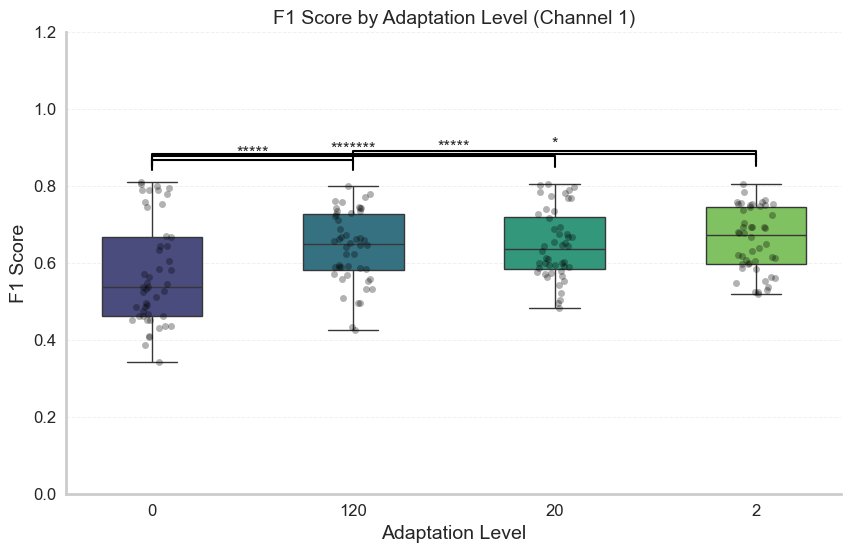

In [26]:
def plot_f1_boxplot_by_adapt(df, metric="F1"):
    # Define specific order
    desired_order = [0, 120, 20, 2]
    # Filter to only include values present in the dataframe
    adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Boxplot
    sns.boxplot(x="Adapt", y=metric, data=df, ax=ax, palette="viridis", width=0.5, showfliers=False, order=adapt_values)
    sns.stripplot(x="Adapt", y=metric, data=df, ax=ax, color="black", alpha=0.3, jitter=True, order=adapt_values)
    
    # Statistical annotation (Wilcoxon)
    # Pivot using Dataset and Network as identifiers for paired comparison
    pivot_cols = ["Session", "Network"]
    
    # Check if we have duplicates (e.g. multiple networks)
    # If multiple networks, we might need to include Network in pivot or average
    # The provided dataframe has 'Network', 'Dataset', 'Channel'. 
    # Since we filtered for Channel 1, 'Dataset' and 'Network' should be unique per Adapt level 
    # UNLESS there are multiple runs.
    
    pivot = df.pivot_table(index=pivot_cols, columns="Adapt", values=metric)
    pivot = pivot.dropna()
    print(f"N={len(pivot)} matched samples for statistics.")
    
    if len(pivot) > 0:
        centers = range(len(adapt_values))
        # Calculate max height for annotations
        max_val = df[metric].max()
        
        combinations = list(itertools.combinations(range(len(adapt_values)), 2))
        for idx, (i, j) in enumerate(combinations):
            a1 = adapt_values[i]
            a2 = adapt_values[j]
            
            if a1 not in pivot.columns or a2 not in pivot.columns:
                continue

            v1 = pivot[a1].values
            v2 = pivot[a2].values
            
            # Check if we have enough samples for Wilcoxon
            if len(v1) >= 3:
                stat, p = wilcoxon(v1, v2)
                
                # Stacking logic for brackets
                h = max_val + 0.05 * (1 + idx) * (max_val * 0.1)
                
                if p < 0.05:
                    print(f"{a1} vs {a2}: p={p:.4f}")
                    barplot_annotate_brackets(i, j, p, centers, [h]*len(centers), ax)
            else:
                print(f"Skipping stats for {a1} vs {a2}: N={len(v1)} too small")
    
    ax.grid(True, axis='y', linestyle='--',linewidth=0.7,alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)           
    ax.set_title(f"{metric} Score by Adaptation Level (Channel 1)",fontsize=14)
    ax.set_ylim(0, 1.2) # Adjust to fit brackets
    ax.set_ylabel(f"{metric} Score",fontsize=14)
    ax.set_xlabel("Adaptation Level",fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    plt.show()


plot_f1_boxplot_by_adapt(df_ch1, "F1")
 

C:\Users\NCN\AppData\Local\Temp\ipykernel_23536\2622318961.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Adapt", y=metric, data=df, ax=ax, palette="viridis", inner="quartile", cut=0, order=adapt_values)


0 vs 120: p=0.0000
0 vs 20: p=0.0000
0 vs 2: p=0.0000
120 vs 20: p=0.0036


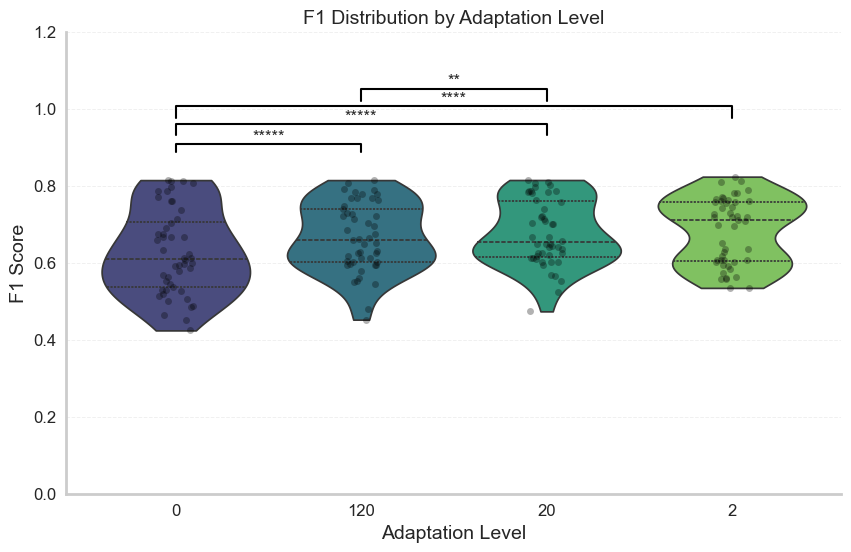

In [43]:
def plot_f1_violin_by_adapt(df, metric="F1"):
    # Define specific order
    desired_order = [0, 120, 20, 2]
    # Filter to only include values present in the dataframe
    adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Violin plot
    sns.violinplot(x="Adapt", y=metric, data=df, ax=ax, palette="viridis", inner="quartile", cut=0, order=adapt_values)
    # Overlay points
    sns.stripplot(x="Adapt", y=metric, data=df, ax=ax, color="black", alpha=0.3, jitter=True, order=adapt_values)
    
    # Statistical annotation (Wilcoxon)
    pivot_cols = ["Session", "Network"]
    
    pivot = df.pivot_table(index=pivot_cols, columns="Adapt", values=metric)
    pivot = pivot.dropna()
    
    if len(pivot) > 0:
        centers = range(len(adapt_values))
        max_val = df[metric].max()
        
        combinations = list(itertools.combinations(range(len(adapt_values)), 2))
        for idx, (i, j) in enumerate(combinations):
            a1 = adapt_values[i]
            a2 = adapt_values[j]
            
            if a1 not in pivot.columns or a2 not in pivot.columns:
                continue

            v1 = pivot[a1].values
            v2 = pivot[a2].values
            
            # Check if we have enough samples for Wilcoxon
            if len(v1) >= 3:
                stat, p = wilcoxon(v1, v2)
                
                # Stacking logic for brackets
                h = max_val + 0.5 * (1 + idx) * (max_val * 0.1)
                
                if p < 0.05:
                    print(f"{a1} vs {a2}: p={p:.4f}")
                    barplot_annotate_brackets(i, j, p, centers, [h]*len(centers), ax)
            else:
                print(f"Skipping stats for {a1} vs {a2}: N={len(v1)} too small")
    
    ax.grid(True, axis='y', linestyle='--',linewidth=0.7,alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)           
    ax.set_title(f"{metric} Distribution by Adaptation Level",fontsize=14)
    ax.set_ylim(0, 1.2) # Adjust to fit brackets
    ax.set_ylabel(f"{metric} Score",fontsize=14)
    ax.set_xlabel("Adaptation Level",fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    plt.show()

plot_f1_violin_by_adapt(df_parallel, "F1")

C:\Users\NCN\AppData\Local\Temp\ipykernel_23536\2805344189.py:23: RuntimeWarning: divide by zero encountered in divide
  y = (f1 * x) / (2 * x - f1)


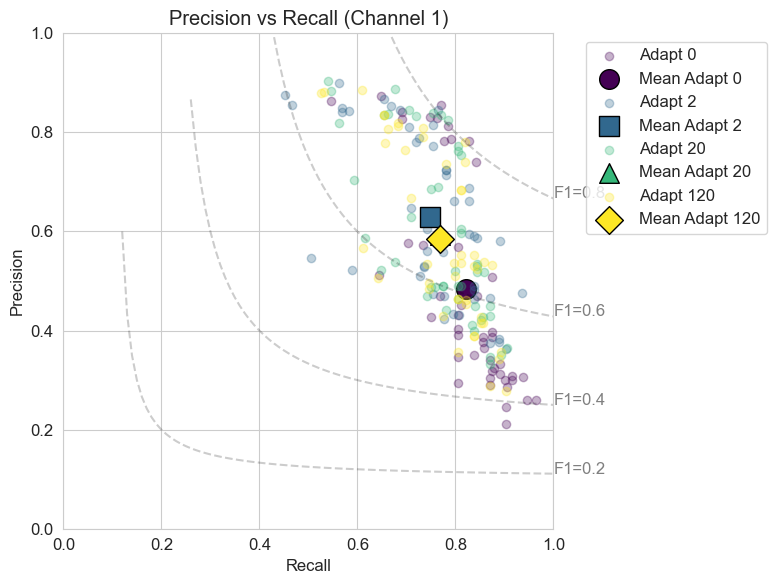

In [28]:
def plot_precision_recall(df):
    plt.figure(figsize=(8, 6))
    
    adapt_values = sorted(df["Adapt"].unique())
    markers = ['o', 's', '^', 'D']
    colors = plt.cm.viridis(np.linspace(0, 1, len(adapt_values)))
    
    for i, adapt in enumerate(adapt_values):
        subset = df[df["Adapt"] == adapt]
        
        # Mean point
        mean_p = subset["Precision"].mean()
        mean_r = subset["Recall"].mean()
        
        plt.scatter(subset["Recall"], subset["Precision"], label=f"Adapt {adapt}", alpha=0.3, color=colors[i])
        plt.scatter(mean_r, mean_p, s=200, edgecolor='black', marker=markers[i%len(markers)], 
                    label=f"Mean Adapt {adapt}", color=colors[i])
        
    # F1 isolines
    f1_scores = [0.2, 0.4, 0.6, 0.8]
    x = np.linspace(0.01, 1, 100)
    for f1 in f1_scores:
        y = (f1 * x) / (2 * x - f1)
        # Filter valid y
        valid = (y >= 0) & (y <= 1)
        plt.plot(x[valid], y[valid], 'k--', alpha=0.2)
        if any(valid):
            plt.text(x[valid][-1], y[valid][-1], f"F1={f1}", color='gray')
        
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision vs Recall (Channel 1)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_precision_recall(df_ch1)

    
